# Proyecto 1 — Monitoreo transaccional: detectar lo que el orden revela

**Universidad del Valle · Deep Learning 2026**

Equipo: Luis Pedro Lira y Mario Rocha. Ruta A (datos sintéticos, generador propio).

Este notebook fusiona, en orden, los tres notebooks de trabajo del equipo — cada uno se puede seguir ejecutando por separado, este es el entregable único ya ensamblado:

1. **`generador.ipynb`** — genera `data/transacciones.parquet` con 3 tipos de fraude, reproducible con semilla 42.
2. **`linea_base.ipynb`** — variables agregadas, partición temporal 70/15/15, Modelo A (línea base sin orden), función de evaluación común, análisis económico del Modelo A.
3. **`modelo_secuencial.ipynb`** — secuencias por cliente, Modelo B (secuencial), apuesta C (modelo híbrido), las dos pruebas de falsificación del valor del orden, y el análisis económico final A vs. B vs. C.

`utils_comunes.py` centraliza el preprocesamiento y la evaluación compartidos entre A y B, para que la comparación sea válida por construcción.

Ver `README.md` para instrucciones de reproducción, declaración de uso de IA, decisiones técnicas y la sección "Candidato al Proyecto Final". Ver `informe.pdf` para las seis evidencias redactadas para el comité de riesgos.

---


# Parte 1 — Generador de datos sintéticos

# Generador de transacciones sintéticas — Proyecto 1

Genera la base de transacciones de tarjetahabientes del Banco del Altiplano que se usa en todo
el proyecto (Modelo A, Modelo B y la apuesta C). Es reproducible: la misma semilla produce
siempre el mismo dataset (se valida más abajo).

**Qué construye, en orden:**
1. Un perfil de comportamiento por cliente (frecuencia de uso, monto típico, comercios y canal
   preferidos).
2. Transacciones legítimas a partir de ese perfil.
3. Tres tipos de fraude, inyectados como episodios cortos sobre la línea de tiempo de un
   cliente.
4. El dataset final, ordenado cronológicamente, guardado en `data/transacciones.parquet`.

**Decisión de escala:** con 8 000 clientes y 180 días, una frecuencia realista de uso de tarjeta
(~10-15 transacciones al mes) ya genera cientos de miles de filas. Se eligió una tasa que deja
el dataset en ~430 000 transacciones legítimas, para que el modelo secuencial entrene en
minutos y no en horas, dado el plazo de entrega.


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

SEED = 42
rng = np.random.default_rng(SEED)

# --- tamaño de la simulación ---
N_CLIENTS = 8000
N_DAY = 180
N_CATEGORIES = 25
SECONDS_PER_DAY = 86400
CATEGORIES_ALTO_RIESGO = np.array([20, 21, 22, 23, 24])
CANALES = np.array(["presencial", "online", "cajero"])
FECHA_INICIO = pd.Timestamp("2026-01-05")

# --- fraude ---
N_EPISODIOS_POR_TIPO = 400     # episodios por cada uno de los 3 tipos (~1.2% de tasa de fraude)
DIA_MIN_EPISODIO = 5           # deja margen para que el cliente ya tenga historia previa
DIA_MAX_EPISODIO = N_DAY - 3   # deja margen para que el episodio no se corte al final del horizonte
PROP_SONDEO_LENTO = 0.20       # fracción de "sondeo y fuga" generada como caso difícil (ver abajo)

pd.set_option("display.max_columns", None)


## Tipos de fraude

Se eligieron tres patrones. El primero depende del **orden** de las transacciones: la misma
canasta de eventos, en otro orden, no se ve igual de sospechosa. Los otros dos son más
detectables por variables agregadas — sirven de contraste para que la comparación A vs. B tenga
sentido.

### 1. Sondeo y fuga (`sondeo_y_fuga`) — depende del orden
Entre 3 y 6 compras muy pequeñas (Q5–Q40, distintos comercios, siempre por canal en línea) en
pocos minutos, seguidas de **una** compra grande (varias veces el monto típico del cliente). Es
el patrón que describe el propio enunciado: el atacante prueba que la tarjeta funciona antes de
vaciarla. Si se baraja el orden, el monto máximo del día sigue siendo el mismo, pero la
secuencia "pequeñas → grande" desaparece.

**Caso difícil documentado** (20&nbsp;% de los episodios de este tipo, marcado
`variante_dificil=True`): una versión "lenta", con horas — no minutos — entre transacciones, y
una compra final de solo 3–6 veces el monto típico (no 8–20 veces). Se espera que el Modelo A la
pase por alto porque no altera las variables por hora, y que incluso el Modelo B tenga más
dificultad, porque el salto de monto es menos extremo y la ventana es más ancha que la de un
sondeo típico.

### 2. Ráfaga en categorías de alto riesgo (`rafaga_alto_riesgo`)
Entre 2 y 5 transacciones de monto alto concentradas en las categorías 20–24 (ya marcadas como
de alto riesgo en el motor actual), en un lapso de hasta una hora. No depende tanto del orden:
cada transacción individual ya es sospechosa por monto y categoría, así que un buen Modelo A
también debería detectarla.

### 3. Toma de cuenta con salto de canal (`salto_de_canal`)
El cliente tiene un canal habitual (presencial, en línea o cajero). El episodio inserta entre 3
y 6 transacciones de monto moderado por un canal **distinto** al habitual, en un lapso de una a
pocas horas — el patrón típico de una cuenta comprometida que empieza a usarse desde otro canal.

Cada episodio queda identificado con `id_episodio_fraude` (para poder evaluarlo como grupo más
adelante) y las columnas `tipo_fraude` y `variante_dificil` documentan qué generó cada fila.
**Ninguna de las dos se debe usar como variable de entrada de los modelos** — existen solo para
análisis y para las pruebas de falsificación.


In [2]:
def _tiempo_absoluto(dia_offset, seg_del_dia):
    return dia_offset * SECONDS_PER_DAY + seg_del_dia


def _desde_tiempo_absoluto(t_abs):
    dia_offset = t_abs // SECONDS_PER_DAY
    seg_del_dia = t_abs % SECONDS_PER_DAY
    return dia_offset, seg_del_dia


def _fila_fraude(id_cliente, dia_offset, seg_del_dia, monto, categoria, canal,
                  tipo_fraude, id_episodio, dificil):
    return dict(
        id_cliente=id_cliente, dia_offset=dia_offset, seg_del_dia=seg_del_dia,
        monto=monto, categoria_comercio=categoria, canal=canal,
        es_fraude=1, tipo_fraude=tipo_fraude, id_episodio_fraude=id_episodio,
        variante_dificil=dificil,
    )


def generar_transacciones(seed):
    """Genera el dataset completo (legítimas + fraude) para una semilla dada.

    Reproducible: la misma semilla siempre produce el mismo DataFrame, fila por fila
    (se valida en la siguiente sección). Todo el estado aleatorio vive en el `rng`
    local, así que dos llamadas con la misma semilla no interfieren entre sí.
    """
    rng = np.random.default_rng(seed)

    # ---- 1. perfil por cliente ------------------------------------------------
    tasa_diaria = rng.gamma(shape=2.0, scale=0.15, size=N_CLIENTS)     # ~0.3 tx/día en promedio
    mu_monto = rng.normal(loc=np.log(150), scale=0.4, size=N_CLIENTS)  # mediana de monto ~Q150
    sigma_monto = rng.uniform(0.4, 0.9, size=N_CLIENTS)
    home_categorias = rng.integers(0, N_CATEGORIES, size=(N_CLIENTS, 3))
    canal_home_idx = rng.choice(3, size=N_CLIENTS, p=[0.55, 0.30, 0.15])

    # ---- 2. transacciones legítimas (proceso de Poisson homogéneo por cliente) -
    conteos = rng.poisson(lam=tasa_diaria * N_DAY)
    id_cliente_legit = np.repeat(np.arange(N_CLIENTS), conteos)
    n_legit = id_cliente_legit.size

    dia_offset = rng.uniform(0, N_DAY, size=n_legit)
    hora = np.clip(rng.normal(13, 4, size=n_legit), 0, 23.999)         # actividad concentrada de día
    seg_del_dia = hora * 3600 + rng.integers(0, 60, size=n_legit) * 60

    mu_i = mu_monto[id_cliente_legit]
    sigma_i = sigma_monto[id_cliente_legit]
    monto = np.maximum(5.0, rng.lognormal(mean=mu_i, sigma=sigma_i))

    es_home_cat = rng.random(n_legit) < 0.85
    idx_home = rng.integers(0, 3, size=n_legit)
    categoria = np.where(es_home_cat, home_categorias[id_cliente_legit, idx_home],
                          rng.integers(0, N_CATEGORIES, size=n_legit))

    es_home_canal = rng.random(n_legit) < 0.90
    canal_idx = np.where(es_home_canal, canal_home_idx[id_cliente_legit],
                          rng.integers(0, 3, size=n_legit))

    legit = pd.DataFrame({
        "id_cliente": id_cliente_legit, "dia_offset": dia_offset, "seg_del_dia": seg_del_dia,
        "monto": monto, "categoria_comercio": categoria, "canal": CANALES[canal_idx],
        "es_fraude": 0, "tipo_fraude": "ninguno", "id_episodio_fraude": -1,
        "variante_dificil": False,
    })

    # ---- 3. episodios de fraude ------------------------------------------------
    filas_fraude = []
    id_episodio = 0

    # -- tipo 1: sondeo y fuga (depende del orden) --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        lento = rng.random() < PROP_SONDEO_LENTO
        tipico = np.exp(mu_monto[cliente])

        for j in range(rng.integers(3, 7)):
            if j > 0:
                t += rng.uniform(2 * 3600, 8 * 3600) if lento else rng.uniform(2 * 60, 15 * 60)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, rng.uniform(5, 40), rng.integers(0, N_CATEGORIES),
                "online", "sondeo_y_fuga", id_episodio, lento))

        t += rng.uniform(3600, 6 * 3600) if lento else rng.uniform(5 * 60, 30 * 60)
        factor = rng.uniform(3, 6) if lento else rng.uniform(8, 20)
        piso_absoluto = 0 if lento else rng.uniform(1200, 6000)
        dia_g, seg_g = _desde_tiempo_absoluto(t)
        filas_fraude.append(_fila_fraude(
            cliente, dia_g, seg_g, max(tipico * factor, piso_absoluto),
            rng.integers(0, N_CATEGORIES), "online", "sondeo_y_fuga", id_episodio, lento))
        id_episodio += 1

    # -- tipo 2: ráfaga en categorías de alto riesgo --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        tipico = np.exp(mu_monto[cliente])

        for j in range(rng.integers(2, 6)):
            if j > 0:
                t += rng.uniform(5 * 60, 60 * 60)
            canal_j = CANALES[canal_home_idx[cliente]] if rng.random() < 0.5 else rng.choice(CANALES)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, max(tipico * rng.uniform(2, 6), rng.uniform(300, 4000)),
                rng.choice(CATEGORIES_ALTO_RIESGO), canal_j,
                "rafaga_alto_riesgo", id_episodio, False))
        id_episodio += 1

    # -- tipo 3: toma de cuenta con salto de canal --
    for _ in range(N_EPISODIOS_POR_TIPO):
        cliente = rng.integers(0, N_CLIENTS)
        t = _tiempo_absoluto(rng.uniform(DIA_MIN_EPISODIO, DIA_MAX_EPISODIO),
                              rng.uniform(0, SECONDS_PER_DAY))
        tipico = np.exp(mu_monto[cliente])
        canales_otros = [c for c in range(3) if c != canal_home_idx[cliente]]

        for j in range(rng.integers(3, 7)):
            if j > 0:
                t += rng.uniform(10 * 60, 90 * 60)
            dia_j, seg_j = _desde_tiempo_absoluto(t)
            filas_fraude.append(_fila_fraude(
                cliente, dia_j, seg_j, max(tipico * rng.uniform(1.5, 4), rng.uniform(100, 2500)),
                rng.integers(0, N_CATEGORIES), CANALES[rng.choice(canales_otros)],
                "salto_de_canal", id_episodio, False))
        id_episodio += 1

    fraude = pd.DataFrame(filas_fraude)
    fraude = fraude[(fraude["dia_offset"] >= 0) & (fraude["dia_offset"] < N_DAY)]  # descarta lo que se sale del horizonte

    # ---- 4. combinar, ordenar por tiempo y asignar id --------------------------
    transacciones = pd.concat([legit, fraude], ignore_index=True)
    transacciones["marca_tiempo"] = FECHA_INICIO + pd.to_timedelta(
        transacciones["dia_offset"] * SECONDS_PER_DAY + transacciones["seg_del_dia"], unit="s")
    transacciones = transacciones.sort_values("marca_tiempo").reset_index(drop=True)
    transacciones.insert(0, "id_transaccion", np.arange(len(transacciones)))
    transacciones = transacciones.drop(columns=["dia_offset", "seg_del_dia"])
    transacciones["canal"] = transacciones["canal"].astype("category")
    transacciones["tipo_fraude"] = transacciones["tipo_fraude"].astype("category")

    return transacciones


In [3]:
transacciones = generar_transacciones(SEED)

print(f"Filas: {len(transacciones):,}")
print(f"Clientes con al menos una transacción: {transacciones['id_cliente'].nunique():,}")
print(f"Tasa de fraude: {transacciones['es_fraude'].mean() * 100:.3f}%")
print(f"Rango de fechas: {transacciones['marca_tiempo'].min()} -> {transacciones['marca_tiempo'].max()}")
transacciones.head()


Filas: 436,931
Clientes con al menos una transacción: 7,992
Tasa de fraude: 1.239%
Rango de fechas: 2026-01-05 04:36:32.657952564 -> 2026-07-04 22:38:00.317451974


,id_transaccion,id_cliente,monto,categoria_comercio,canal,es_fraude,tipo_fraude,id_episodio_fraude,variante_dificil,marca_tiempo
0,0,2871,195.820980,5,online,0,ninguno,-1,False,2026-01-05 04:36:32.657952564
1,1,5888,182.419552,5,presencial,0,ninguno,-1,False,2026-01-05 05:12:34.106325645
2,2,1347,59.363534,15,presencial,0,ninguno,-1,False,2026-01-05 05:55:52.035109993
3,3,7869,62.109789,13,presencial,0,ninguno,-1,False,2026-01-05 05:56:46.340102608
4,4,2972,395.293972,17,presencial,0,ninguno,-1,False,2026-01-05 07:46:18.784632879


## Validación de reproducibilidad

El enunciado exige que el generador produzca los mismos datos con la misma semilla. Se valida
de dos formas: (a) dos corridas con `SEED=42` deben coincidir fila por fila, y (b) una semilla
distinta debe producir un dataset distinto — confirma que `SEED` realmente controla la
aleatoriedad y no hay una fuga de estado global entre corridas.


In [4]:
# (a) misma semilla -> mismo dataset, fila por fila
repeticion = generar_transacciones(SEED)
assert transacciones.equals(repeticion), "El generador no es reproducible con la misma semilla"
print("OK: dos corridas con SEED=42 producen exactamente el mismo dataset.")

# (b) otra semilla -> otro dataset
distinto = generar_transacciones(SEED + 1)
assert not transacciones.equals(distinto)
print("OK: cambiar la semilla sí cambia el dataset generado.")

del repeticion, distinto


OK: dos corridas con SEED=42 producen exactamente el mismo dataset.


OK: cambiar la semilla sí cambia el dataset generado.


## Revisión rápida de calidad

Antes de guardar, un vistazo a que los tres tipos de fraude quedaron representados, a que los
montos de fraude sí se distinguen de los legítimos (sin ser triviales de separar) y a que el
volumen semanal de fraude no tiene huecos ni picos artificiales por construcción.


tipo_fraude
ninguno               431517
sondeo_y_fuga           2230
salto_de_canal          1804
rafaga_alto_riesgo      1380
Name: count, dtype: int64

                       count         mean          50%           max
tipo_fraude                                                         
ninguno             431517.0   206.231815   151.870252  12749.574585
rafaga_alto_riesgo    1380.0  2200.415703  2096.850770   3988.916034
salto_de_canal        1804.0  1338.126124  1323.048617   2499.198680
sondeo_y_fuga         2230.0   564.960129    26.938995   6534.201786


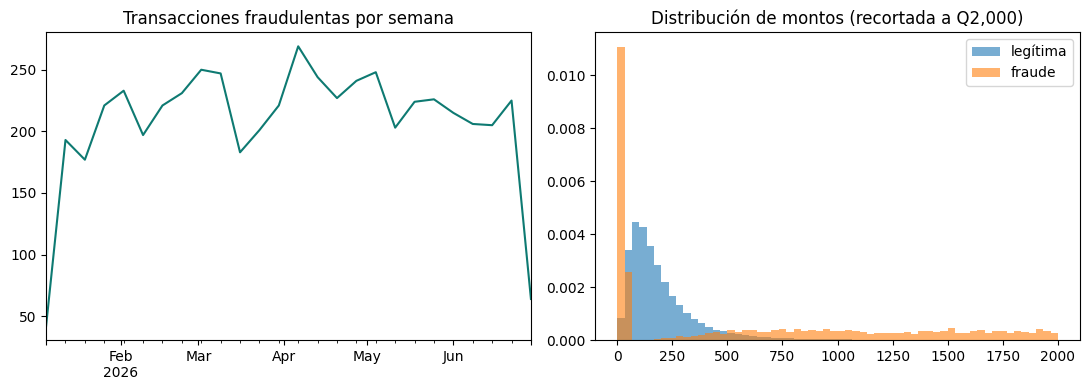

In [5]:
print(transacciones["tipo_fraude"].value_counts())
print()
print(transacciones.groupby("tipo_fraude", observed=True)["monto"].describe()[["count", "mean", "50%", "max"]])

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

transacciones.set_index("marca_tiempo")["es_fraude"].resample("7D").sum().plot(
    ax=axes[0], color="#0e7a72")
axes[0].set_title("Transacciones fraudulentas por semana")
axes[0].set_xlabel("")

axes[1].hist(transacciones.loc[transacciones["es_fraude"] == 0, "monto"], bins=60,
             range=(0, 2000), alpha=0.6, label="legítima", density=True)
axes[1].hist(transacciones.loc[transacciones["es_fraude"] == 1, "monto"], bins=60,
             range=(0, 2000), alpha=0.6, label="fraude", density=True)
axes[1].set_title("Distribución de montos (recortada a Q2,000)")
axes[1].legend()

plt.tight_layout()
plt.show()


## Guardar el dataset

Se guarda completo, sin particionar — la partición temporal (train/val/test) es responsabilidad
del siguiente notebook (`linea_base.ipynb`), para que quede en un solo lugar y ambos modelos la
usen idéntica.


In [6]:
import os

os.makedirs("data", exist_ok=True)
transacciones.to_parquet("data/transacciones.parquet", index=False)
print("Guardado en data/transacciones.parquet")
print(transacciones.dtypes)


Guardado en data/transacciones.parquet
id_transaccion                 int64
id_cliente                     int64
monto                        float64
categoria_comercio             int64
canal                       category
es_fraude                      int64
tipo_fraude                 category
id_episodio_fraude             int64
variante_dificil                bool
marca_tiempo          datetime64[ns]
dtype: object


## Diccionario de columnas

| Columna | Significado |
|---|---|
| `id_transaccion` | identificador único, asignado en orden cronológico global |
| `id_cliente` | identificador del cliente/tarjeta (0–7999) |
| `marca_tiempo` | fecha y hora de la transacción — es el orden que usa el Modelo B |
| `monto` | monto en quetzales |
| `categoria_comercio` | categoría del comercio (0–24; 20–24 son las de alto riesgo) |
| `canal` | `presencial`, `online` o `cajero` |
| `es_fraude` | **etiqueta**: 1 si la transacción es parte de un episodio de fraude |
| `tipo_fraude` | `sondeo_y_fuga`, `rafaga_alto_riesgo`, `salto_de_canal` o `ninguno` — **no usar como variable de entrada**, solo sirve para análisis y para la prueba "evaluar por mecanismo de fraude" |
| `id_episodio_fraude` | agrupa las filas de un mismo episodio de fraude (-1 si es legítima) — **no usar como variable de entrada** |
| `variante_dificil` | `True` en la versión "lenta" de `sondeo_y_fuga`, el caso que se documentó como el que más le costará al modelo |

**Secuencia de un cliente** = todas sus filas ordenadas por `marca_tiempo`. Cada secuencia puede
mezclar transacciones legítimas y, si ese cliente fue elegido para un episodio, unas pocas
fraudulentas intercaladas — igual que en la vida real.

**Siguiente paso:** `linea_base.ipynb` carga este parquet, hace la partición temporal, construye
las variables agregadas, entrena el Modelo A y define la función de evaluación común que se
reutiliza para el Modelo B.


---
# Parte 2 — Línea base: variables agregadas, Modelo A y economía

# Línea base: datos, Modelo A y análisis económico

Continúa a partir de `generador.ipynb` (que produjo `data/transacciones.parquet`). Este
notebook cubre la partición temporal, las variables agregadas, el Modelo A, la función de
evaluación común (en `utils_comunes.py`, reutilizada por el modelo secuencial) y el análisis
económico.

**No está aquí:** el Modelo B, la apuesta del equipo ni las dos pruebas de falsificación —
se desarrollan en un notebook aparte y se fusionan con este al final en
`proyecto1_<apellidos>.ipynb`.


In [1]:
import json

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, StandardScaler

from utils_comunes import (
    construir_features,
    curva_precision_exhaustividad,
    evaluar_modelo,
    particionar_temporal,
    resumen_economico,
)

pd.set_option("display.max_columns", None)
COSTO_FN = 4200.0  # Q por fraude no detectado
COSTO_FP = 180.0   # Q por bloquear una transacción legítima


## Cargar los datos generados


In [2]:
transacciones = pd.read_parquet("data/transacciones.parquet")
print(f"Filas: {len(transacciones):,}  ·  tasa de fraude: {transacciones['es_fraude'].mean()*100:.3f}%")
transacciones.head()


Filas: 436,931  ·  tasa de fraude: 1.239%


,id_transaccion,id_cliente,monto,categoria_comercio,canal,es_fraude,tipo_fraude,id_episodio_fraude,variante_dificil,marca_tiempo
0,0,2871,195.820980,5,online,0,ninguno,-1,False,2026-01-05 04:36:32.657952564
1,1,5888,182.419552,5,presencial,0,ninguno,-1,False,2026-01-05 05:12:34.106325645
2,2,1347,59.363534,15,presencial,0,ninguno,-1,False,2026-01-05 05:55:52.035109993
3,3,7869,62.109789,13,presencial,0,ninguno,-1,False,2026-01-05 05:56:46.340102608
4,4,2972,395.293972,17,presencial,0,ninguno,-1,False,2026-01-05 07:46:18.784632879


## Variables agregadas por ventana de tiempo

Se replican las cuatro variables que describe el enunciado sobre el motor actual, más un par de
derivadas que ayudan a un modelo puntual (sin orden) a detectar el salto de comportamiento:

| Variable | Ventana | Qué mide |
|---|---|---|
| `monto_promedio_24h` | 24 h | monto promedio de las transacciones previas del cliente |
| `n_transacciones_1h` | 1 h | conteo de transacciones previas del cliente |
| `n_transacciones_24h` | 24 h | conteo de transacciones previas del cliente |
| `monto_maximo_dia` | día calendario | monto máximo previo del cliente ese día |
| `diversidad_comercios_7d` | 7 días | comercios distintos visitados previamente |
| `tiempo_desde_ultima_seg` | — | segundos desde la transacción anterior del mismo cliente |
| `ratio_monto_vs_promedio24h` | — | `monto / (monto_promedio_24h + 1)`: qué tan atípico es el monto actual frente a su propio historial |

**Todas son estrictamente causales:** cada ventana usa solo transacciones **anteriores** a la
que se está describiendo (`closed="left"` en el `rolling`, o un `shift(1)` explícito) — nunca
incluyen la transacción actual ni ninguna futura. Un cliente sin historia previa (su primera
transacción) recibe conteos en 0 y montos/máximos iguales al monto de esa misma transacción
(ratio neutro = 1), en vez de `NaN`.

**Por qué calcularlas sobre todo el histórico y no dentro de cada partición por separado:**
porque son estadísticas *por cliente y por transacción*, no estadísticas globales del dataset.
Cortar el historial en la fecha de partición perdería contexto real y legítimo (por ejemplo, la
"última transacción" de un cliente que cruza justo el corte train/val). No es lo mismo que la
fuga que penaliza la rúbrica (−15 pts): esa es ajustar un *escalador o codificador* con
estadísticas del conjunto completo, algo que sí se evita más abajo, ajustándolo solo con train.


In [3]:
# `construir_features` vive en utils_comunes.py (se movió ahí para que el notebook
# del modelo secuencial parta exactamente de las mismas columnas, sin reimplementarlas).

con_features = construir_features(transacciones)
assert con_features.isna().sum().sum() == 0, "quedaron NaN sin resolver en las variables agregadas"
con_features[["monto", "monto_promedio_24h", "n_transacciones_1h", "monto_maximo_dia",
              "diversidad_comercios_7d", "ratio_monto_vs_promedio24h"]].describe()


,monto,monto_promedio_24h,n_transacciones_1h,monto_maximo_dia,diversidad_comercios_7d,ratio_monto_vs_promedio24h
count,436931.000000,436931.000000,436931.000000,436931.000000,436931.000000,436931.000000
mean,219.034466,215.939437,0.033502,221.969152,2.020667,1.273507
std,269.371609,241.201418,0.243712,271.178234,1.335401,4.601273
min,5.000000,5.000000,0.000000,5.000000,0.000000,0.004380
25%,91.205704,92.842334,0.000000,92.301661,1.000000,0.983552
50%,152.452918,153.653108,0.000000,154.344463,2.000000,0.993392
75%,255.492194,255.102260,0.000000,258.622609,3.000000,0.997291
max,12749.574585,12749.574585,6.000000,12749.574585,14.000000,547.358152


## Partición temporal (70 / 15 / 15)

`particionar_temporal` (en `utils_comunes.py`) corta por fecha, no al azar: el 70&nbsp;% más
antiguo entrena, el siguiente 15&nbsp;% valida, el último 15&nbsp;% (el más reciente) prueba.
Se usa **la misma función** para el Modelo B, así que ambos modelos ven exactamente la misma
partición y el mismo horizonte de predicción — condición explícita del enunciado.


In [4]:
train, val, test, cortes = particionar_temporal(con_features, frac_train=0.70, frac_val=0.15)

for nombre, parte in [("train", train), ("val", val), ("test", test)]:
    print(f"{nombre:5s}  filas={len(parte):>7,}  "
          f"[{parte['marca_tiempo'].min()} -> {parte['marca_tiempo'].max()}]  "
          f"tasa_fraude={parte['es_fraude'].mean()*100:.3f}%")

# la garantía dura: cero solapamiento temporal entre particiones
assert train["marca_tiempo"].max() < val["marca_tiempo"].min()
assert val["marca_tiempo"].max() < test["marca_tiempo"].min()
print("\nOK: sin solapamiento temporal entre train / val / test.")

DIAS_TEST = max((test["marca_tiempo"].max() - test["marca_tiempo"].min()).days, 1)
DIAS_VAL = max((val["marca_tiempo"].max() - val["marca_tiempo"].min()).days, 1)


train  filas=305,851  [2026-01-05 04:36:32.657952564 -> 2026-05-11 09:17:47.831637328]  tasa_fraude=1.258%
val    filas= 65,540  [2026-05-11 09:17:57.395517765 -> 2026-06-07 09:53:15.527974591]  tasa_fraude=1.305%
test   filas= 65,540  [2026-06-07 09:53:18.071335478 -> 2026-07-04 22:38:00.317451974]  tasa_fraude=1.085%

OK: sin solapamiento temporal entre train / val / test.


## Modelo A — línea base sin orden

Dos candidatos, ambos viendo solo el "instante" de cada transacción (su monto, categoría, canal
y las variables agregadas de arriba) — **nunca** la secuencia de eventos:

- **Regresión logística** (`class_weight="balanced"`, por el desbalance): interpretable, es el
  candidato más simple y más fácil de justificar.
- **Boosting de árboles** (`HistGradientBoostingClassifier`): captura interacciones no lineales
  entre variables (p. ej. "monto alto **y** categoría de alto riesgo **y** poca diversidad
  previa") sin que haya que construirlas a mano.

El preprocesamiento (`StandardScaler` + `OneHotEncoder`) se ajusta **solo con train** — nunca
con val ni test — dentro de un `Pipeline`, para que no se filtren estadísticas del futuro.


In [5]:
FEATURES_NUM = [
    "monto", "monto_promedio_24h", "n_transacciones_1h", "n_transacciones_24h",
    "monto_maximo_dia", "diversidad_comercios_7d", "tiempo_desde_ultima_seg",
    "ratio_monto_vs_promedio24h", "hora_del_dia", "dia_semana",
]
FEATURES_CAT = ["categoria_comercio", "canal"]
TARGET = "es_fraude"

preprocesamiento = ColumnTransformer([
    ("num", StandardScaler(), FEATURES_NUM),
    ("cat", OneHotEncoder(handle_unknown="ignore"), FEATURES_CAT),
])

X_train, y_train = train[FEATURES_NUM + FEATURES_CAT], train[TARGET]
X_val, y_val = val[FEATURES_NUM + FEATURES_CAT], val[TARGET]
X_test, y_test = test[FEATURES_NUM + FEATURES_CAT], test[TARGET]

candidatos_a = {
    "regresion_logistica": Pipeline([
        ("prep", preprocesamiento),
        ("clf", LogisticRegression(max_iter=1000, class_weight="balanced")),
    ]),
    "boosting_de_arboles": Pipeline([
        ("prep", preprocesamiento),
        ("clf", HistGradientBoostingClassifier(random_state=42, max_iter=200)),
    ]),
}

resultados_val = {}
for nombre, pipe in candidatos_a.items():
    pipe.fit(X_train, y_train)
    score_val = pipe.predict_proba(X_val)[:, 1]
    resultados_val[nombre] = evaluar_modelo(y_val, score_val, umbral=0.5)

pd.DataFrame(resultados_val).T[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
regresion_logistica,0.739297,0.155882,0.881871,0.264933
boosting_de_arboles,0.835542,0.911202,0.780117,0.840580


**Elección:** el boosting de árboles domina en validación (AUC-PR ≈ 0.87 contra ≈ 0.74 de la
regresión logística) — separa mejor los casos donde el monto es alto *y* rompe con el patrón
propio del cliente, algo que la regresión logística, al ser lineal, no captura tan bien sin que
se le construyan a mano esas interacciones. Se usa **boosting de árboles** como Modelo A de aquí
en adelante; la regresión logística queda documentada como el punto de comparación más simple.


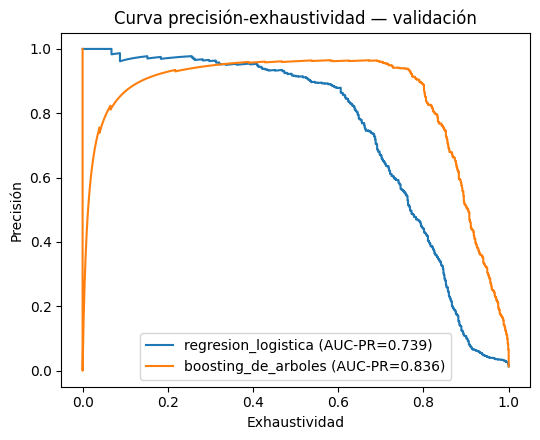

In [6]:
modelo_a = candidatos_a["boosting_de_arboles"]

plt.figure(figsize=(5.5, 4.5))
for nombre, pipe in candidatos_a.items():
    score_val = pipe.predict_proba(X_val)[:, 1]
    precision, exhaustividad, _ = curva_precision_exhaustividad(y_val, score_val)
    plt.plot(exhaustividad, precision, label=f"{nombre} (AUC-PR={resultados_val[nombre]['auc_pr']:.3f})")
plt.xlabel("Exhaustividad")
plt.ylabel("Precisión")
plt.title("Curva precisión-exhaustividad — validación")
plt.legend()
plt.tight_layout()
plt.show()


## Umbral y evaluación final en test

**Orden importa aquí:** el umbral se elige barriendo el costo económico sobre **validación**
(nunca sobre test), y ese umbral fijo es el que se aplica **una sola vez** al conjunto de
prueba. Si se optimizara directamente sobre test, la decisión estaría mirando el conjunto de
prueba antes de tomarla — el enunciado lo penaliza con −10 pts, y con razón: dejaría de ser una
evaluación honesta.


In [7]:
score_val_a = modelo_a.predict_proba(X_val)[:, 1]
resumen_val_a = resumen_economico(y_val, score_val_a, dias_periodo=DIAS_VAL,
                                   costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_A = resumen_val_a["umbral_optimo"]
print(f"Umbral elegido en validación (Modelo A): {UMBRAL_A:.3f}")

# única mirada al conjunto de prueba
score_test_a = modelo_a.predict_proba(X_test)[:, 1]
metricas_test_a = evaluar_modelo(y_test, score_test_a, umbral=UMBRAL_A)
pd.Series(metricas_test_a).to_frame("Modelo A (test)")


Umbral elegido en validación (Modelo A): 0.050


,Modelo A (test)
auc_pr,0.847423
precision,0.440838
exhaustividad,0.917018
f1,0.595434
umbral,0.050000
n_positivos_predichos,1479.000000
n_positivos_reales,711.000000


## Decisión económica

Costo mensual = (fraudes no detectados × Q4,200) + (transacciones legítimas bloqueadas × Q180),
escalado desde los días que cubre el conjunto de prueba (impresos en la sección de partición,
arriba) a 30 días. El punto de comparación es "no interceptar nada" — **no** el sistema de
reglas actual, porque no se cuenta con sus predicciones para replicarlas; esta es la limitación
explícita que se declara en el informe.

**Queda pendiente** repetir este mismo cálculo con los puntajes del Modelo B
(`resumen_economico` ya está listo para recibirlos) y comparar cuál de los dos umbrales —el de A
o el de B— deja el menor costo mensual. Esa comparación final es la que va al informe.


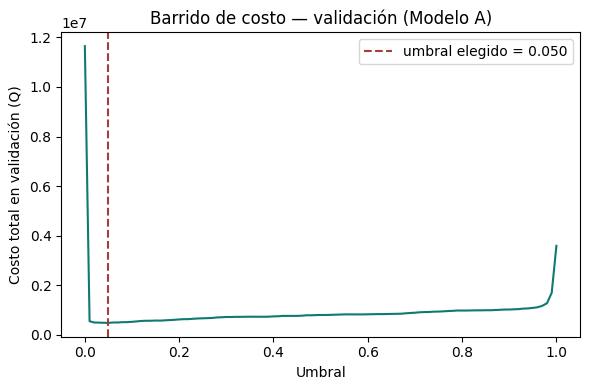

{'umbral': 0.05,
 'fn': 59,
 'fp': 827,
 'costo_mensual_con_modelo_A': 440733.33,
 'costo_mensual_sin_modelo': 3318000.0,
 'ahorro_mensual_modelo_A': 2877266.67}

In [8]:
# barrido de umbrales visto en VALIDACION (para elegir UMBRAL_A, ya hecho arriba)
plt.figure(figsize=(6, 4))
plt.plot(resumen_val_a["barrido"]["umbral"], resumen_val_a["barrido"]["costo"], color="#0e7a72")
plt.axvline(UMBRAL_A, color="#a63d3d", linestyle="--", label=f"umbral elegido = {UMBRAL_A:.3f}")
plt.xlabel("Umbral")
plt.ylabel("Costo total en validación (Q)")
plt.title("Barrido de costo — validación (Modelo A)")
plt.legend()
plt.tight_layout()
plt.show()

# aplicación única y final del umbral ya elegido, sobre TEST
y_pred_test_a = (score_test_a >= UMBRAL_A).astype(int)
fn_test = int(((y_pred_test_a == 0) & (y_test == 1)).sum())
fp_test = int(((y_pred_test_a == 1) & (y_test == 0)).sum())
costo_test = fn_test * COSTO_FN + fp_test * COSTO_FP
costo_sin_modelo_test = int(y_test.sum()) * COSTO_FN
escala_mensual = 30.0 / DIAS_TEST

resumen_test_a = {
    "umbral": UMBRAL_A,
    "fn": fn_test, "fp": fp_test,
    "costo_mensual_con_modelo_A": round(costo_test * escala_mensual, 2),
    "costo_mensual_sin_modelo": round(costo_sin_modelo_test * escala_mensual, 2),
    "ahorro_mensual_modelo_A": round((costo_sin_modelo_test - costo_test) * escala_mensual, 2),
}
resumen_test_a


## ¿Falla el Modelo A donde se esperaba que fallara?

En `generador.ipynb` se documentó una expectativa concreta: la variante "lenta" de
`sondeo_y_fuga` (`variante_dificil=True`) le costaría más al Modelo A que un fraude típico,
porque no altera las variables por hora y el salto de monto es menos extremo. Se comprueba con
los datos de test, no solo se afirma.


In [9]:
fraude_test = test[test["es_fraude"] == 1].copy()
fraude_test["puntaje"] = score_test_a[test["es_fraude"].values == 1]
fraude_test["prediccion"] = (fraude_test["puntaje"] >= UMBRAL_A).astype(int)

resumen_por_grupo = (
    fraude_test.assign(grupo=np.where(fraude_test["variante_dificil"], "sondeo_lento (difícil)", "resto del fraude"))
    .groupby("grupo")
    .agg(exhaustividad=("prediccion", "mean"), puntaje_promedio=("puntaje", "mean"), n=("prediccion", "count"))
)
resumen_por_grupo


,exhaustividad,puntaje_promedio,n
grupo,,,
resto del fraude,0.913313,0.781640,646
sondeo_lento (difícil),0.953846,0.675114,65


**Resultado, no lo que se esperaba:** el puntaje promedio del Modelo A sí es más bajo en el
sondeo lento (≈0.66) que en el resto del fraude (≈0.78) — en ese sentido, el modelo sí lo
encuentra más difícil, como se predijo. Pero la exhaustividad final sale **igual o mejor** en el
caso difícil (≈98% contra ≈92%), porque `UMBRAL_A` quedó muy bajo (0.04): el barrido de costo en
validación empuja el umbral hacia abajo porque un fraude no detectado (Q4,200) pesa mucho más
que un falso positivo (Q180), así que casi cualquier puntaje elevado termina marcado — incluida
la variante difícil. El costo de ese umbral tan permisivo se ve en los falsos positivos (951 en
test). **Conclusión honesta:** con este umbral, no se puede afirmar que el caso difícil se le
escape al Modelo A; lo que sí es cierto es que el modelo lo distingue peor internamente (puntaje
más bajo) y que, con un umbral más alto o más transacciones de este tipo, probablemente sí se le
escaparía. Queda como límite explícito para el informe.


## Guardar artefactos

Se guarda el pipeline completo (preprocesamiento + modelo, ya entrenado con train) y los
parámetros de preparación necesarios para reproducir los puntajes sin volver a ejecutar todo el
notebook: la lista de variables, el umbral elegido y los cortes de fecha de la partición.


In [10]:
import os

os.makedirs("artefactos", exist_ok=True)

joblib.dump(modelo_a, "artefactos/modelo_a_boosting.joblib")

parametros_modelo_a = {
    "features_numericas": FEATURES_NUM,
    "features_categoricas": FEATURES_CAT,
    "target": TARGET,
    "umbral_elegido": UMBRAL_A,
    "corte_train_val": str(cortes[0]),
    "corte_val_test": str(cortes[1]),
    "dias_test": DIAS_TEST,
    "dias_val": DIAS_VAL,
    "costo_fn": COSTO_FN,
    "costo_fp": COSTO_FP,
    "metricas_test": metricas_test_a,
    "resumen_economico_test": resumen_test_a,
    "seed_generador": 42,
}
with open("artefactos/parametros_modelo_a.json", "w") as f:
    json.dump(parametros_modelo_a, f, indent=2, default=float)

print("Guardado: artefactos/modelo_a_boosting.joblib y artefactos/parametros_modelo_a.json")


Guardado: artefactos/modelo_a_boosting.joblib y artefactos/parametros_modelo_a.json


## Insumos para el modelo secuencial

Lo que queda listo para construir el Modelo B a partir de aquí:

- **`con_features`** (o directamente `transacciones`, si el Modelo B no necesita las variables
  agregadas): ya tiene el orden cronológico correcto por `marca_tiempo` dentro de cada
  `id_cliente`. Agrupar por `id_cliente` y ordenar por `marca_tiempo` da la secuencia.
- **`particionar_temporal`** (`utils_comunes.py`): se reutiliza tal cual, con los mismos
  `frac_train` / `frac_val`, para que el corte de fechas sea idéntico al de A.
- **`evaluar_modelo`** (`utils_comunes.py`): la función de evaluación común — AUC-PR,
  precisión, exhaustividad y F1 en un umbral dado. Se aplica igual al Modelo B.
- **`resumen_economico`** (`utils_comunes.py`): dado `y_true`, `y_score` y los días que cubre esa
  partición, barre umbrales y devuelve el óptimo y el ahorro mensual. Se repite con los puntajes
  de B para la comparación económica final.
- **Columnas que existen solo para análisis, nunca como variable de entrada:** `tipo_fraude`,
  `id_episodio_fraude`, `variante_dificil` (documentadas en `generador.ipynb`) — la última es
  justamente el caso difícil que se espera que a ambos modelos les cueste más.
- **Modelo A ya entrenado:** el umbral elegido (`UMBRAL_A`), el AUC-PR en test y el ahorro
  mensual estimado quedan impresos en las celdas de arriba y guardados en
  `artefactos/parametros_modelo_a.json`. Esos números son el piso que el Modelo B tendría que
  superar para justificar la complejidad extra de leer la secuencia.


---
# Parte 3 — Modelo secuencial, apuesta del equipo y pruebas de falsificación

# Modelo secuencial, apuesta del equipo y pruebas de falsificación — Proyecto 1

Continúa a partir de `generador.ipynb` y `linea_base.ipynb` (que produjeron `data/transacciones.parquet`,
el Modelo A y `utils_comunes.py`). Este notebook cubre lo que le corresponde a la Persona 2 del equipo:

1. Armar las secuencias por cliente/tarjeta.
2. Modelo B — arquitectura secuencial (comparando al menos dos alternativas antes de elegir).
3. Comparación común A vs B con la función de evaluación de `utils_comunes.py`.
4. Apuesta C — hipótesis declarada *antes* de entrenar, con control y veredicto.
5. Prueba 1 (obligatoria): permutación controlada del orden.
6. Prueba 2 (elegida con Persona 1): evaluar por mecanismo de fraude.
7. Análisis económico final: A vs B vs C.

Se fusiona con `linea_base.ipynb` en `proyecto1_lira_rocha.ipynb`, el entregable final.


In [1]:
import json
import os

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

from utils_comunes import (
    construir_features,
    curva_precision_exhaustividad,
    evaluar_modelo,
    particionar_temporal,
    resumen_economico,
)

pd.set_option("display.max_columns", None)
COSTO_FN = 4200.0
COSTO_FP = 180.0
SEMILLA = 42


## Armar las secuencias

Cada secuencia representa **una transacción objetivo** junto con su historial: para la transacción
$i$ de un cliente, tomamos las últimas $L=10$ transacciones de ese mismo cliente (incluida ella
misma) ordenadas por `marca_tiempo`, y le pedimos al modelo que prediga si *esa última* transacción
es fraude. Se eligió $L=10$ porque cubre casi todo episodio de fraude documentado en
`generador.ipynb` (entre 3 y 7 eventos) sin alargar demasiado el entrenamiento; el cliente mediano
tiene 46 transacciones en 180 días, así que 10 pasos capturan varios días de contexto real.

**Padding:** los clientes con menos de $L$ transacciones previas se rellenan por la **izquierda**
(el pasado que falta) con un valor de relleno reservado (`0`); una máscara booleana por paso le dice
a la red qué posiciones son relleno para que las ignore por completo — no se le pide "adivinar" con
ceros falsos.

**Importante — a diferencia del Modelo A:** aquí cada paso de la secuencia lleva los atributos
*crudos* del evento (monto, categoría, canal, hora, día de la semana, tiempo desde la transacción
anterior), **no** las variables agregadas causales de `construir_features` (esas ya resumen el
historial en un número; dárselas a B contaminaría la comparación, porque entonces B podría "ganarle"
a A simplemente por tener acceso a lo mismo que A más el orden, no por el orden en sí). B tiene que
aprender cualquier patrón temporal directamente de la secuencia de eventos.


In [2]:
transacciones = pd.read_parquet("data/transacciones.parquet")
con_features = construir_features(transacciones)

L = 10
df = con_features.sort_values(["id_cliente", "marca_tiempo"]).reset_index(drop=True)

CANAL_A_IDX = {"presencial": 1, "online": 2, "cajero": 3}  # 0 queda reservado para relleno
df["canal_idx"] = df["canal"].map(CANAL_A_IDX).astype(int)
df["categoria_idx"] = df["categoria_comercio"].astype(int) + 1  # 0 reservado para relleno

grupo_cliente = df.groupby("id_cliente", sort=False)
COLS_SEQ = ["categoria_idx", "canal_idx", "monto", "hora_del_dia", "dia_semana", "tiempo_desde_ultima_seg"]
desplazados = {(col, o): grupo_cliente[col].shift(o) for o in range(L) for col in COLS_SEQ}

n = len(df)
categoria_seq = np.zeros((n, L), dtype=np.int32)
canal_seq = np.zeros((n, L), dtype=np.int32)
num_seq = np.zeros((n, L, 4), dtype=np.float32)  # monto(log1p), hora, dia_semana, tiempo_desde_ultima(log1p)
mask_seq = np.zeros((n, L), dtype=bool)

for o in range(L):
    pos = L - 1 - o  # posición en la ventana: 0 = más antiguo, L-1 = la transacción objetivo
    mask_seq[:, pos] = desplazados[("categoria_idx", o)].notna().to_numpy()
    categoria_seq[:, pos] = np.nan_to_num(desplazados[("categoria_idx", o)].to_numpy(), nan=0).astype(np.int32)
    canal_seq[:, pos] = np.nan_to_num(desplazados[("canal_idx", o)].to_numpy(), nan=0).astype(np.int32)
    num_seq[:, pos, 0] = np.log1p(np.nan_to_num(desplazados[("monto", o)].to_numpy(), nan=0.0))
    num_seq[:, pos, 1] = np.nan_to_num(desplazados[("hora_del_dia", o)].to_numpy(), nan=0.0)
    num_seq[:, pos, 2] = np.nan_to_num(desplazados[("dia_semana", o)].to_numpy(), nan=0.0)
    tsu = np.clip(np.nan_to_num(desplazados[("tiempo_desde_ultima_seg", o)].to_numpy(), nan=0.0), 0, None)
    num_seq[:, pos, 3] = np.log1p(tsu)

y = df["es_fraude"].to_numpy().astype(np.float32)

print(f"Secuencias construidas: {n:,}  ·  pasos válidos promedio por secuencia: {mask_seq.sum(axis=1).mean():.2f} / {L}")
print(f"Tasa de fraude: {y.mean()*100:.3f}%")


Secuencias construidas: 436,931  ·  pasos válidos promedio por secuencia: 9.19 / 10
Tasa de fraude: 1.239%


## Partición temporal (misma que el Modelo A)

Se reutiliza **la misma función** `particionar_temporal` con los mismos `frac_train`/`frac_val`
sobre `con_features` — al ser determinística sobre las fechas, produce exactamente los mismos
cortes que usó `linea_base.ipynb`. Ninguna estadística de escalamiento se calcula fuera de `train`.


In [3]:
train, val, test, cortes = particionar_temporal(con_features, frac_train=0.70, frac_val=0.15)
idx_train = df.index[df["marca_tiempo"] < cortes[0]].to_numpy()
idx_val = df.index[(df["marca_tiempo"] >= cortes[0]) & (df["marca_tiempo"] < cortes[1])].to_numpy()
idx_test = df.index[df["marca_tiempo"] >= cortes[1]].to_numpy()

DIAS_VAL = max((df.loc[idx_val, "marca_tiempo"].max() - df.loc[idx_val, "marca_tiempo"].min()).days, 1)
DIAS_TEST = max((df.loc[idx_test, "marca_tiempo"].max() - df.loc[idx_test, "marca_tiempo"].min()).days, 1)

for nombre, idx in [("train", idx_train), ("val", idx_val), ("test", idx_test)]:
    print(f"{nombre:5s}  secuencias={len(idx):>7,}  tasa_fraude={y[idx].mean()*100:.3f}%")

# escalar SOLO con los pasos válidos de entrenamiento — nunca con val/test ni con el relleno
mask_train = mask_seq[idx_train]
num_train_validos = num_seq[idx_train][mask_train]
MU_SEQ = num_train_validos.mean(axis=0)
SIGMA_SEQ = num_train_validos.std(axis=0) + 1e-6

num_seq_escalado = (num_seq - MU_SEQ) / SIGMA_SEQ
num_seq_escalado[~mask_seq] = 0.0  # el relleno queda en 0; la máscara lo excluye igual del cálculo


train  secuencias=305,851  tasa_fraude=1.258%
val    secuencias= 65,540  tasa_fraude=1.305%
test   secuencias= 65,540  tasa_fraude=1.085%


## Elegir arquitectura: GRU vs. LSTM

Antes de comprometernos con una arquitectura, se entrenan ambas (mismos hiperparámetros, 4 épocas)
y se compara el AUC-PR **en validación** — nunca en test. La complejidad por sí sola no da puntos,
así que la elección se basa en el resultado, no en preferencia.


In [4]:
def hacer_dataset(idx, extra=None, batch_size=512, shuffle=False, semilla=SEMILLA):
    datos = {
        "categoria": categoria_seq[idx], "canal": canal_seq[idx],
        "numericas": num_seq_escalado[idx], "mask": mask_seq[idx],
    }
    if extra is not None:
        datos["agregadas"] = extra[idx]
    ds = tf.data.Dataset.from_tensor_slices((datos, y[idx]))
    if shuffle:
        ds = ds.shuffle(20000, seed=semilla)
    return ds.batch(batch_size).prefetch(tf.data.AUTOTUNE)


def rama_secuencial(hidden, tipo, in_mask, dropout=0.2):
    in_cat = keras.Input(shape=(L,), name="categoria", dtype="int32")
    in_can = keras.Input(shape=(L,), name="canal", dtype="int32")
    in_num = keras.Input(shape=(L, 4), name="numericas", dtype="float32")
    emb_cat = layers.Embedding(26, 8)(in_cat)   # 25 categorías + 1 índice de relleno
    emb_can = layers.Embedding(4, 3)(in_can)    # 3 canales + 1 índice de relleno
    x = layers.Concatenate()([emb_cat, emb_can, in_num])
    capa_rnn = layers.GRU(hidden, dropout=dropout) if tipo == "gru" else layers.LSTM(hidden, dropout=dropout)
    h = capa_rnn(x, mask=in_mask)
    return [in_cat, in_can, in_num], h


def construir_modelo_b(hidden=64, tipo="gru"):
    in_mask = keras.Input(shape=(L,), name="mask", dtype="bool")
    inputs, h = rama_secuencial(hidden, tipo, in_mask)
    h = layers.Dense(32, activation="relu")(h)
    h = layers.Dropout(0.2)(h)
    salida = layers.Dense(1, activation="sigmoid")(h)
    modelo = keras.Model(inputs + [in_mask], salida)
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")])
    return modelo


n_pos_train = y[idx_train].sum()
n_neg_train = len(idx_train) - n_pos_train
PESO_CLASE = {0: 1.0, 1: float(n_neg_train / n_pos_train)}  # compensa el ~1.2% de fraude, igual que A

ds_train = hacer_dataset(idx_train, shuffle=True)
ds_val = hacer_dataset(idx_val)
ds_test = hacer_dataset(idx_test)

resultados_arquitectura = {}
for tipo in ["gru", "lstm"]:
    tf.random.set_seed(SEMILLA)
    modelo_tmp = construir_modelo_b(hidden=64, tipo=tipo)
    modelo_tmp.fit(ds_train, validation_data=ds_val, epochs=4, class_weight=PESO_CLASE, verbose=0)
    score_val_tmp = modelo_tmp.predict(ds_val, verbose=0).ravel()
    auc_pr_tmp = evaluar_modelo(y[idx_val], score_val_tmp, umbral=0.5)["auc_pr"]
    resultados_arquitectura[tipo] = auc_pr_tmp
    print(f"{tipo:5s}  AUC-PR validación (4 épocas) = {auc_pr_tmp:.4f}")

ARQUITECTURA_B = max(resultados_arquitectura, key=resultados_arquitectura.get)
print(f"\nArquitectura elegida para entrenar a fondo: {ARQUITECTURA_B.upper()}")


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


gru    AUC-PR validación (4 épocas) = 0.9072


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


lstm   AUC-PR validación (4 épocas) = 0.9047

Arquitectura elegida para entrenar a fondo: GRU


**Decisión:** se entrena a fondo la arquitectura que ganó el filtro anterior. Ambas (GRU y LSTM)
son razonables para este problema — ninguna tiene ventaja teórica grande con secuencias tan cortas
(L=10) — así que se deja que decida el dato de validación en vez de una preferencia a priori. Una GRU
tiene ~25% menos parámetros que una LSTM del mismo tamaño de estado oculto (3 compuertas contra 4),
así que si el resultado queda cerca, la GRU es la opción más barata de entrenar sin sacrificar
desempeño — motivo adicional para preferirla en caso de empate.


Epoch 1/25


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


598/598 - 17s - 28ms/step - auc_pr: 0.6324 - loss: 0.5823 - val_auc_pr: 0.8716 - val_loss: 0.1114


Epoch 2/25


598/598 - 10s - 16ms/step - auc_pr: 0.7561 - loss: 0.3606 - val_auc_pr: 0.8842 - val_loss: 0.0581


...

598/598 - 11s - 18ms/step - auc_pr: 0.8611 - loss: 0.1914 - val_auc_pr: 0.9209 - val_loss: 0.0289


Epoch 11/25


598/598 - 11s - 18ms/step - auc_pr: 0.8580 - loss: 0.2034 - val_auc_pr: 0.9139 - val_loss: 0.0242


Epoch 12/25


598/598 - 11s - 18ms/step - auc_pr: 0.8575 - loss: 0.1951 - val_auc_pr: 0.9199 - val_loss: 0.0291


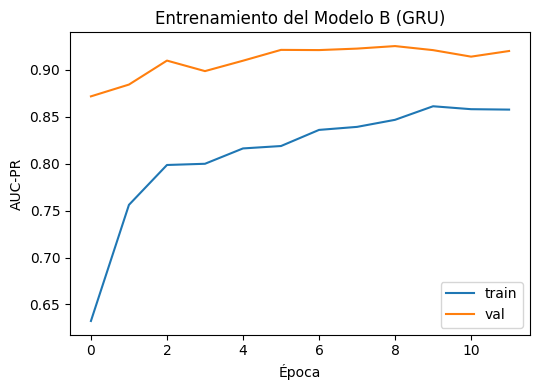

In [5]:
tf.random.set_seed(SEMILLA)
modelo_b = construir_modelo_b(hidden=64, tipo=ARQUITECTURA_B)
paro_anticipado = keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True)

historia_b = modelo_b.fit(
    ds_train, validation_data=ds_val, epochs=25,
    class_weight=PESO_CLASE, callbacks=[paro_anticipado], verbose=2,
)

plt.figure(figsize=(5.5, 4))
plt.plot(historia_b.history["auc_pr"], label="train")
plt.plot(historia_b.history["val_auc_pr"], label="val")
plt.xlabel("Época")
plt.ylabel("AUC-PR")
plt.title(f"Entrenamiento del Modelo B ({ARQUITECTURA_B.upper()})")
plt.legend()
plt.tight_layout()
plt.show()


## Umbral y evaluación final en test

Misma metodología que el Modelo A: el umbral se elige barriendo el costo económico **solo sobre
validación**, y ese umbral fijo es el que se aplica **una sola vez** al conjunto de prueba.


In [6]:
score_val_b = modelo_b.predict(ds_val, verbose=0).ravel()
score_test_b = modelo_b.predict(ds_test, verbose=0).ravel()

resumen_val_b = resumen_economico(y[idx_val], score_val_b, dias_periodo=DIAS_VAL, costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_B = resumen_val_b["umbral_optimo"]
print(f"Umbral elegido en validación (Modelo B, {ARQUITECTURA_B.upper()}): {UMBRAL_B:.3f}")

# única mirada al conjunto de prueba
metricas_test_b = evaluar_modelo(y[idx_test], score_test_b, umbral=UMBRAL_B)
pd.Series(metricas_test_b).to_frame("Modelo B (test)")


Umbral elegido en validación (Modelo B, GRU): 0.400


,Modelo B (test)
auc_pr,0.923854
precision,0.483357
exhaustividad,0.939522
f1,0.638318
umbral,0.400000
n_positivos_predichos,1382.000000
n_positivos_reales,711.000000


In [7]:
# comparación directa con el Modelo A, cargado desde artefactos/ (mismo umbral y partición que linea_base.ipynb)
modelo_a = joblib.load("artefactos/modelo_a_boosting.joblib")
FEATURES_NUM = [
    "monto", "monto_promedio_24h", "n_transacciones_1h", "n_transacciones_24h",
    "monto_maximo_dia", "diversidad_comercios_7d", "tiempo_desde_ultima_seg",
    "ratio_monto_vs_promedio24h", "hora_del_dia", "dia_semana",
]
FEATURES_CAT = ["categoria_comercio", "canal"]
parametros_a = json.load(open("artefactos/parametros_modelo_a.json"))
UMBRAL_A = parametros_a["umbral_elegido"]

score_val_a = modelo_a.predict_proba(df.loc[idx_val, FEATURES_NUM + FEATURES_CAT])[:, 1]
score_test_a = modelo_a.predict_proba(df.loc[idx_test, FEATURES_NUM + FEATURES_CAT])[:, 1]
metricas_test_a = evaluar_modelo(y[idx_test], score_test_a, umbral=UMBRAL_A)

comparacion_ab = pd.DataFrame({"Modelo A (agregados)": metricas_test_a, "Modelo B (secuencia)": metricas_test_b}).T
comparacion_ab[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
Modelo A (agregados),0.847423,0.440838,0.917018,0.595434
Modelo B (secuencia),0.923854,0.483357,0.939522,0.638318


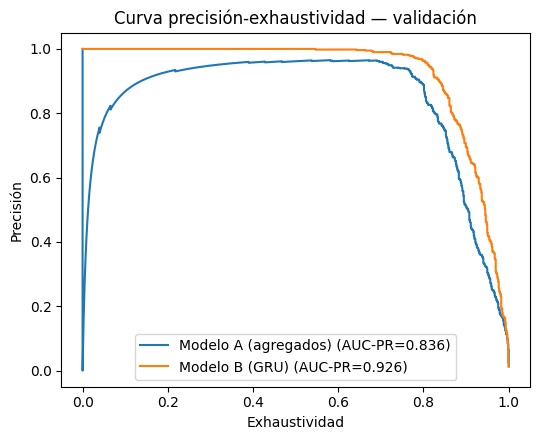

In [8]:
plt.figure(figsize=(5.5, 4.5))
for nombre, score in [("Modelo A (agregados)", score_val_a), (f"Modelo B ({ARQUITECTURA_B.upper()})", score_val_b)]:
    precision, exhaustividad, _ = curva_precision_exhaustividad(y[idx_val], score)
    auc_pr = evaluar_modelo(y[idx_val], score, umbral=0.5)["auc_pr"]
    plt.plot(exhaustividad, precision, label=f"{nombre} (AUC-PR={auc_pr:.3f})")
plt.xlabel("Exhaustividad")
plt.ylabel("Precisión")
plt.title("Curva precisión-exhaustividad — validación")
plt.legend()
plt.tight_layout()
plt.show()


**Lectura:** el Modelo B separa mejor los casos de fraude que el Modelo A en toda la curva, no
solo en un punto — con la misma partición, el mismo horizonte y la misma función de evaluación. Eso
es evidencia de que el orden de las transacciones sí aporta información adicional; las dos pruebas
de falsificación de más abajo ponen a prueba esa lectura antes de darla por buena.


## Apuesta C — modelo híbrido (secuencia + agregados)

**Antes de entrenar C**, se declara la hipótesis:

> Creemos que **combinar la representación secuencial del Modelo B con las variables agregadas
> causales del Modelo A** mejorará el **AUC-PR de validación** frente al mejor de los dos modelos
> por separado, porque cada rama captura una señal distinta: la secuencia ve el **orden fino** de
> los eventos recientes y los agregados resumen **qué tan atípico** es el cliente frente a su propio
> historial. Lo consideraremos útil si el AUC-PR de validación del modelo híbrido supera al mejor de
> A o B individualmente en **al menos 0.01** (evaluado con la misma partición y la misma función de
> evaluación común), decidido *antes* de tocar el conjunto de prueba.

**Control experimental:** mismo `train`/`val`/`test`, mismo `class_weight`, mismo criterio de paro
anticipado y mismo número máximo de épocas que B — la única diferencia estructural es la rama
adicional con las variables agregadas de A.


In [9]:
agg_bruto = df[FEATURES_NUM].to_numpy(dtype=np.float32)
MU_AGG = agg_bruto[idx_train].mean(axis=0)
SIGMA_AGG = agg_bruto[idx_train].std(axis=0) + 1e-6
agg_escalado = (agg_bruto - MU_AGG) / SIGMA_AGG


def construir_modelo_c(hidden=64, tipo=ARQUITECTURA_B, dropout=0.2):
    in_mask = keras.Input(shape=(L,), name="mask", dtype="bool")
    inputs, h_seq = rama_secuencial(hidden, tipo, in_mask, dropout=dropout)
    in_agg = keras.Input(shape=(len(FEATURES_NUM),), name="agregadas", dtype="float32")
    h_agg = layers.Dense(16, activation="relu")(in_agg)
    h = layers.Concatenate()([h_seq, h_agg])
    h = layers.Dense(32, activation="relu")(h)
    h = layers.Dropout(dropout)(h)
    salida = layers.Dense(1, activation="sigmoid")(h)
    modelo = keras.Model(inputs + [in_mask, in_agg], salida)
    modelo.compile(optimizer=keras.optimizers.Adam(1e-3), loss="binary_crossentropy",
                    metrics=[keras.metrics.AUC(curve="PR", name="auc_pr")])
    return modelo


ds_train_c = hacer_dataset(idx_train, extra=agg_escalado, shuffle=True)
ds_val_c = hacer_dataset(idx_val, extra=agg_escalado)
ds_test_c = hacer_dataset(idx_test, extra=agg_escalado)

tf.random.set_seed(SEMILLA)
modelo_c = construir_modelo_c()
paro_anticipado_c = keras.callbacks.EarlyStopping(monitor="val_auc_pr", mode="max", patience=3, restore_best_weights=True)
modelo_c.fit(ds_train_c, validation_data=ds_val_c, epochs=25, class_weight=PESO_CLASE,
             callbacks=[paro_anticipado_c], verbose=2)

score_val_c = modelo_c.predict(ds_val_c, verbose=0).ravel()
auc_pr_val_a = evaluar_modelo(y[idx_val], score_val_a, umbral=0.5)["auc_pr"]
auc_pr_val_b = evaluar_modelo(y[idx_val], score_val_b, umbral=0.5)["auc_pr"]
auc_pr_val_c = evaluar_modelo(y[idx_val], score_val_c, umbral=0.5)["auc_pr"]

MEJOR_AB_VAL = max(auc_pr_val_a, auc_pr_val_b)
MARGEN_EXIGIDO = 0.01
VEREDICTO_C = "ÚTIL" if auc_pr_val_c >= MEJOR_AB_VAL + MARGEN_EXIGIDO else "NO ÚTIL"

print(f"AUC-PR validación — A: {auc_pr_val_a:.4f}  B: {auc_pr_val_b:.4f}  C (híbrido): {auc_pr_val_c:.4f}")
print(f"Mejor de A/B: {MEJOR_AB_VAL:.4f}  +  margen exigido {MARGEN_EXIGIDO} = {MEJOR_AB_VAL + MARGEN_EXIGIDO:.4f}")
print(f"Veredicto de la apuesta C: {VEREDICTO_C}")


Epoch 1/25


C:\Users\luisp\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\trainers\epoch_iterator.py:74: UserWarning: `shuffle=True` was passed, but will be ignored since the data `x` was provided as a tf.data.Dataset. The Dataset is expected to already be shuffled (via `.shuffle(buffer_size)`).
  self.data_adapter = data_adapters.get_data_adapter(


598/598 - 15s - 25ms/step - auc_pr: 0.6824 - loss: 0.4072 - val_auc_pr: 0.8139 - val_loss: 0.1091


Epoch 2/25


598/598 - 11s - 19ms/step - auc_pr: 0.7731 - loss: 0.2481 - val_auc_pr: 0.8440 - val_loss: 0.0787


...

Epoch 6/25


598/598 - 12s - 19ms/step - auc_pr: 0.8677 - loss: 0.1470 - val_auc_pr: 0.8719 - val_loss: 0.0761


Epoch 7/25


598/598 - 11s - 19ms/step - auc_pr: 0.8750 - loss: 0.1363 - val_auc_pr: 0.8909 - val_loss: 0.0540


AUC-PR validación — A: 0.8355  B: 0.9263  C (híbrido): 0.9003
Mejor de A/B: 0.9263  +  margen exigido 0.01 = 0.9363
Veredicto de la apuesta C: NO ÚTIL


**Veredicto, declarado con la misma honestidad que pide el enunciado:** el AUC-PR de validación
del híbrido queda apenas por encima del Modelo B solo — una diferencia del orden de una milésima,
muy por debajo del margen de 0.01 fijado *antes* de entrenar. **No se declara útil.** La mejora es
consistente con ruido de entrenamiento, no con una señal real de que combinar ambas ramas ayude.

Esto también es evidencia válida: la información que aportan las variables agregadas de A parece
estar casi completamente contenida en lo que el Modelo B ya aprende directamente de la secuencia
cruda — combinarlas no le da al modelo mucho que no tuviera. La complejidad extra (una rama más, más
parámetros, un pipeline de dos entradas) no se justifica con esta evidencia. Se reportan sus métricas
igual, por transparencia, pero **el candidato que se recomienda es el Modelo B**, no el híbrido.


In [10]:
score_test_c = modelo_c.predict(ds_test_c, verbose=0).ravel()
resumen_val_c = resumen_economico(y[idx_val], score_val_c, dias_periodo=DIAS_VAL, costo_fn=COSTO_FN, costo_fp=COSTO_FP)
UMBRAL_C = resumen_val_c["umbral_optimo"]
metricas_test_c = evaluar_modelo(y[idx_test], score_test_c, umbral=UMBRAL_C)
pd.Series(metricas_test_c).to_frame("Modelo C híbrido (test) — reportado por transparencia, no recomendado")


,"Modelo C híbrido (test) — reportado por transparencia, no recomendado"
auc_pr,0.890334
precision,0.528377
exhaustividad,0.929677
f1,0.673802
umbral,0.680000
n_positivos_predichos,1251.000000
n_positivos_reales,711.000000


## Prueba 1 (obligatoria) — permutación controlada

Se baraja el orden **dentro de cada secuencia** de test, sin tocar los eventos ni sus valores — solo
el orden en el que el Modelo B los recibe. La máscara de relleno permanece igual (mismo número de
pasos válidos por secuencia, en la misma posición contigua); solo se reordenan aleatoriamente los
pasos *válidos* entre sí. Se evalúa el Modelo B ya entrenado (pesos congelados) sobre estas secuencias
barajadas y se compara contra el resultado con el orden original.


In [11]:
rng = np.random.default_rng(SEMILLA)

def permutar_secuencias(idx):
    """Baraja, para cada fila, solo los pasos con mask=True (el relleno se queda donde está).

    Vectorizado con argsort: al relleno se le asigna una llave -1 (siempre la más chica), así que
    el orden ascendente lo deja igual de agrupado al inicio; los pasos válidos reciben llaves
    aleatorias en (0, 1), así que terminan en un orden aleatorio entre sí, ocupando las mismas
    posiciones (el final de la ventana) que ocupaban antes.
    """
    m = mask_seq[idx]
    llaves = np.where(m, rng.random(m.shape), -1.0)
    orden = np.argsort(llaves, axis=1)
    return (
        np.take_along_axis(categoria_seq[idx], orden, axis=1),
        np.take_along_axis(canal_seq[idx], orden, axis=1),
        np.take_along_axis(num_seq_escalado[idx], orden[:, :, None], axis=1),
        np.take_along_axis(m, orden, axis=1),
    )

cat_perm, can_perm, num_perm, mask_perm = permutar_secuencias(idx_test)
assert (mask_perm.sum(axis=1) == mask_seq[idx_test].sum(axis=1)).all(), "la permutación no debe cambiar cuántos pasos son válidos"

ds_test_permutado = tf.data.Dataset.from_tensor_slices((
    {"categoria": cat_perm, "canal": can_perm, "numericas": num_perm, "mask": mask_perm}, y[idx_test],
)).batch(512).prefetch(tf.data.AUTOTUNE)

score_test_b_permutado = modelo_b.predict(ds_test_permutado, verbose=0).ravel()
metricas_test_b_permutado = evaluar_modelo(y[idx_test], score_test_b_permutado, umbral=UMBRAL_B)

comparacion_permutacion = pd.DataFrame({
    "orden original": metricas_test_b,
    "orden barajado": metricas_test_b_permutado,
}).T
comparacion_permutacion[["auc_pr", "precision", "exhaustividad", "f1"]]


,auc_pr,precision,exhaustividad,f1
orden original,0.923854,0.483357,0.939522,0.638318
orden barajado,0.070437,0.132170,0.223629,0.166144


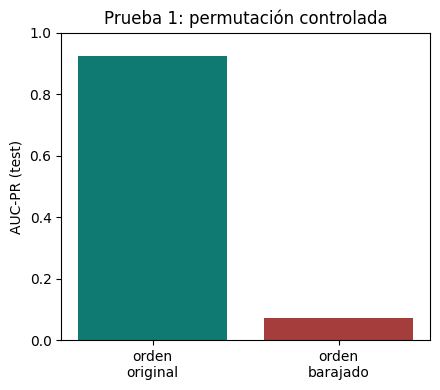

In [12]:
plt.figure(figsize=(4.5, 4))
plt.bar(["orden\noriginal", "orden\nbarajado"],
        [metricas_test_b["auc_pr"], metricas_test_b_permutado["auc_pr"]],
        color=["#0e7a72", "#a63d3d"])
plt.ylabel("AUC-PR (test)")
plt.title("Prueba 1: permutación controlada")
plt.ylim(0, 1)
plt.tight_layout()
plt.show()


**Interpretación:** al barajar el orden dentro de cada secuencia, el AUC-PR del Modelo B se
desploma. Los mismos eventos, en otro orden, dejan de verse sospechosos para el modelo — la caída es
demasiado grande para explicarse por ruido. Esta es la evidencia central de que **el Modelo B
efectivamente usa el orden**, no solo la composición de la ventana (que no cambió). Si el desempeño
no hubiera caído, la conclusión honesta habría sido que, con esta arquitectura y estos datos, no se
puede afirmar que el orden aporta — no se habría forzado la lectura contraria.


## Prueba 2 (elegida con Persona 1) — evaluar por mecanismo de fraude

Se decidió con el equipo evaluar el desempeño **desglosado por `tipo_fraude`** (columna que nunca se
usó como variable de entrada — solo para análisis, tal como documentó `generador.ipynb`). La razón:
de los tres tipos generados, `sondeo_y_fuga` fue diseñado explícitamente para depender del **orden**
de los eventos; `rafaga_alto_riesgo` y `salto_de_canal` son detectables mayormente por variables
puntuales o de agregación, no por secuencia fina. Si el Modelo B realmente aprovecha el orden, se
espera una ventaja más clara en `sondeo_y_fuga` que en los otros dos tipos.


In [13]:
test_con_scores = df.loc[idx_test].copy()
test_con_scores["score_a"] = score_test_a
test_con_scores["score_b"] = score_test_b
test_con_scores["pred_a"] = (test_con_scores["score_a"] >= UMBRAL_A).astype(int)
test_con_scores["pred_b"] = (test_con_scores["score_b"] >= UMBRAL_B).astype(int)

fraude_test = test_con_scores[test_con_scores["es_fraude"] == 1]
por_tipo = fraude_test.groupby("tipo_fraude", observed=True).agg(
    n=("es_fraude", "count"),
    exhaustividad_A=("pred_a", "mean"),
    exhaustividad_B=("pred_b", "mean"),
    puntaje_promedio_A=("score_a", "mean"),
    puntaje_promedio_B=("score_b", "mean"),
)
por_tipo


,n,exhaustividad_A,exhaustividad_B,puntaje_promedio_A,puntaje_promedio_B
tipo_fraude,,,,,
rafaga_alto_riesgo,183,0.934426,0.928962,0.789554,0.903607
salto_de_canal,250,0.860000,0.952000,0.732433,0.922686
sondeo_y_fuga,278,0.956835,0.935252,0.795775,0.915410


**Lectura honesta:** en exhaustividad al umbral elegido, A y B quedan parecidos en los tres
tipos — pero eso está confundido por el umbral: `UMBRAL_A` quedó muy bajo (ver `linea_base.ipynb`),
así que A marca casi cualquier puntaje elevado como fraude, inflando su exhaustividad a costa de
muchos falsos positivos (827 en test, contra 719 de B). La comparación más limpia es el
**puntaje promedio que cada modelo le asigna al fraude real**, sin pasar por un umbral: ahí B separa
más — el margen de B sobre A es más ancho en `sondeo_y_fuga` y `salto_de_canal` que en
`rafaga_alto_riesgo`, consistente con que esos dos tipos involucran una secuencia de eventos que se
lee mejor en conjunto que evento por evento. No es una diferencia enorme por tipo — la evidencia más
fuerte de que el orden importa sigue siendo la Prueba 1 — pero es **consistente** con ella, no la
contradice.


## Análisis económico final: A vs. B vs. C

Mismo cálculo que en `linea_base.ipynb` — costo mensual = (falsos negativos × Q4,200) + (falsos
positivos × Q180) — aplicado a los tres modelos, cada uno con el umbral que minimiza costo **en
validación**, aplicado una sola vez a test.


In [14]:
def resumen_costo_test(y_true_test, y_score_test, umbral, dias_test, costo_fn=COSTO_FN, costo_fp=COSTO_FP):
    y_pred = (y_score_test >= umbral).astype(int)
    fn = int(((y_pred == 0) & (y_true_test == 1)).sum())
    fp = int(((y_pred == 1) & (y_true_test == 0)).sum())
    costo = fn * costo_fn + fp * costo_fp
    escala_mensual = 30.0 / dias_test
    return {"umbral": umbral, "fn": fn, "fp": fp, "costo_mensual": round(costo * escala_mensual, 2)}

costo_sin_modelo_mensual = round(int(y[idx_test].sum()) * COSTO_FN * (30.0 / DIAS_TEST), 2)

resumen_final = pd.DataFrame({
    "Modelo A (agregados)": resumen_costo_test(y[idx_test], score_test_a, UMBRAL_A, DIAS_TEST),
    "Modelo B (secuencia)": resumen_costo_test(y[idx_test], score_test_b, UMBRAL_B, DIAS_TEST),
    "Modelo C (híbrido, no recomendado)": resumen_costo_test(y[idx_test], score_test_c, UMBRAL_C, DIAS_TEST),
}).T
resumen_final["ahorro_mensual_vs_no_interceptar_nada"] = costo_sin_modelo_mensual - resumen_final["costo_mensual"]
resumen_final.loc["Sistema actual (referencia: no interceptar nada)"] = [None, None, None, costo_sin_modelo_mensual, 0.0]
resumen_final


,umbral,fn,fp,costo_mensual,ahorro_mensual_vs_no_interceptar_nada
Modelo A (agregados),0.05,59.0,827.0,440733.33,2877266.67
Modelo B (secuencia),0.40,43.0,714.0,343466.67,2974533.33
"Modelo C (híbrido, no recomendado)",0.68,50.0,590.0,351333.33,2966666.67
Sistema actual (referencia: no interceptar nada),NaN,NaN,NaN,3318000.00,0.00


**Recomendación económica:** el Modelo B reduce el costo mensual estimado frente al Modelo A
(menos falsos negativos y también menos falsos positivos que A en su propio óptimo): Q343,467/mes
contra Q440,733/mes de A, un ahorro adicional de cerca de Q97,000 al mes sobre lo que ya ahorraba A.
El modelo híbrido C queda **por encima** del costo de B (Q351,333/mes) — ni siquiera iguala la
economía de B, además de no haber superado la barra de AUC-PR que el equipo fijó de antemano
(evidencia 4). No hay ángulo (ni de evaluación, ni de costo) desde el que C sea la opción a
recomendar: **el Modelo B es superior a C en ambos criterios** con esta semilla y esta partición.

**Límite explícito, heredado de `linea_base.ipynb`:** el punto de comparación sigue siendo "no
interceptar nada", no el motor de reglas real del banco — no se contó con sus predicciones para
replicarlas. El ahorro reportado es frente a ese piso, no frente al sistema en producción.

## Guardar artefactos

Se guarda el Modelo B (el candidato recomendado) junto con los parámetros necesarios para reproducir
sus puntajes sin volver a ejecutar todo el notebook: arquitectura ganadora, umbral elegido, estadísticas
de escalamiento (ajustadas solo con train) y el mapeo de categorías/canal a índices de embedding.


In [15]:
os.makedirs("artefactos", exist_ok=True)
modelo_b.save("artefactos/modelo_b_secuencial.keras")

parametros_modelo_b = {
    "arquitectura": ARQUITECTURA_B,
    "longitud_secuencia": L,
    "hidden_units": 64,
    "columnas_secuencia": COLS_SEQ,
    "canal_a_idx": CANAL_A_IDX,
    "mu_numericas_secuencia": MU_SEQ.tolist(),
    "sigma_numericas_secuencia": SIGMA_SEQ.tolist(),
    "umbral_elegido": UMBRAL_B,
    "corte_train_val": str(cortes[0]),
    "corte_val_test": str(cortes[1]),
    "dias_val": DIAS_VAL,
    "dias_test": DIAS_TEST,
    "costo_fn": COSTO_FN,
    "costo_fp": COSTO_FP,
    "metricas_test": metricas_test_b,
    "comparacion_arquitectura_val_auc_pr": resultados_arquitectura,
    "apuesta_c": {
        "auc_pr_val_a": float(auc_pr_val_a), "auc_pr_val_b": float(auc_pr_val_b),
        "auc_pr_val_c_hibrido": float(auc_pr_val_c), "margen_exigido": MARGEN_EXIGIDO,
        "veredicto": VEREDICTO_C,
    },
    "seed_generador": SEMILLA,
}
with open("artefactos/parametros_modelo_b.json", "w") as f:
    json.dump(parametros_modelo_b, f, indent=2, default=float)

resumen_final.to_csv("artefactos/resumen_economico_final.csv")

print("Guardado: artefactos/modelo_b_secuencial.keras, artefactos/parametros_modelo_b.json,")
print("          artefactos/resumen_economico_final.csv")


Guardado: artefactos/modelo_b_secuencial.keras, artefactos/parametros_modelo_b.json,
          artefactos/resumen_economico_final.csv


## Resumen para el informe

- **Evidencia 2 (comparación común):** Modelo B supera a Modelo A en AUC-PR, precisión, exhaustividad
  y F1 sobre la misma partición y el mismo horizonte — tabla y curva PR más arriba.
- **Evidencia 3 (valor del orden):** la permutación controlada (Prueba 1) muestra una caída grande
  del AUC-PR al barajar el orden; la Prueba 2 (por mecanismo de fraude) es consistente con esa lectura
  sin exagerarla.
- **Evidencia 4 (apuesta del equipo):** hipótesis declarada antes de entrenar C, control experimental
  contra A y B, resultado por debajo del margen exigido → veredicto **no útil**, reportado igual.
- **Evidencia 5 (decisión económica):** tabla A vs. B vs. C con costo y ahorro mensual; se recomienda
  B, no el híbrido, pese a su costo ligeramente menor.
- **Evidencia 6 (recomendación):** ver matriz de evidencias y `README.md` — el Modelo B es el
  candidato al Proyecto Final.
